# End-to-End Sentiment + Topic Modeling (CIA-3)

This notebook:

- Loads **YouTube comments CSVs** and **video transcripts (TXT)** for **West / Middle East / India**
- Creates **VADER** sentiment scores and **pseudo-labels** (Positive / Neutral / Negative)
- Trains and evaluates **Naive Bayes (NB)**, **Random Forest (RF)**, **SVM** with **Stratified K-Fold cross-validation**
- Runs **LDA topic modeling** separately for each region and for **(a) transcripts** and **(b) comments**
- Produces **word clouds** for each region/source (and optional per-topic clouds)

> Tip: If you already have *ground-truth labels*, replace the VADER pseudo-labeling step with your labels and keep the rest unchanged.


## 0. Setup

If any import fails, install with:

```bash
pip install -U pandas numpy scikit-learn nltk vaderSentiment gensim wordcloud matplotlib
```


In [1]:

import os, re, json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# NLP + ML
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Topic modeling
from sklearn.decomposition import LatentDirichletAllocation

# Wordcloud
from wordcloud import WordCloud

# NLTK stopwords (optional; falls back if unavailable)
try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download("stopwords", quiet=True)
    STOPWORDS = set(stopwords.words("english"))
except Exception:
    STOPWORDS = set()


## 1. File paths (edit if needed)

These match your uploaded files. If you move files, update paths below.


In [2]:
DATA_PATHS = {
  "transcripts": {
    "WEST": {
      "CNN": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\CNN_transcript.txt",
      "BBC": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\BBC_transcript.txt",
      "FOX": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\Fox_transcript.txt"
    },
    "MIDDLE_EAST": {
      "AJ1": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\AJ1_transcript.txt",
      "AJ2": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\AJ2_transcript.txt",
      "AJ3": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\AJ3_transcript.txt"
    },
    "INDIA": {
      "CNBC": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\CNBC_transcript.txt",
      "WION": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\WION_transcript.txt",
      "REPUBLIC": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\Rep_transcript.txt"
    }
  },
  "comments": {
    "WEST": {
      "CNN": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\CNN_US_&_Israel_launch_attack_on_Iran.csv",
      "BBC": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\BBC_Irans_Supreme_Leader_Khamenei_confirmed_killed_in_airstrikes_BBC_News.csv",
      "FOX": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\Fox_BREAKING_US_and_Israel_strike_Iran.csv"
    },
    "MIDDLE_EAST": {
      "AJ1": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\AJ1_Israel_launches_attack_on_Iran,_explosions_in_downtown_Tehran.csv",
      "AJ2": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\AJ2_What_dangers_does_the_US_and_Israel_attack_on_Iran_pose_Inside_Story.csv",
      "AJ3": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\AJ3_Iran_confirms_Supreme_Leader_Ali_Khamenei_dead_after_US-Israeli_attacks.csv"
    },
    "INDIA": {
      "CNBC": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\CNBC_Middle_East_Military_Escalation_Iran_Strikes_US_Bases_in_Qatar_&_Bahrain_Iran_Vs_US_War_N18G.csv",
      "WION": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\WION_Israel-Iran_War_Iran_Begins_Counter_Strike,_Launches_Missiles_Towards_Israel_GRAVITAS_HIGHLIGHT.csv",
      "REPUBLIC": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\Rep_Can_Iran_Defeat_US_&_Israel_In_This_war_Will_Putin_Back_Tehran_The_GD_Bakshi_Podcast.csv"
    }
  }
}

## 2. Load data (comments + transcripts)

We will:
- read each CSV
- automatically detect the most likely **comment text column**
- read each transcript TXT


In [3]:

def read_text_file(path: str) -> str:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    return path.read_text(encoding="utf-8", errors="ignore")

def detect_text_column(df: pd.DataFrame) -> str:
    # Prefer columns that look like comment text
    candidates = []
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in ["comment", "text", "content", "message", "body"]):
            candidates.append(c)
    # If none, pick the longest average string column among object columns
    if candidates:
        return candidates[0]
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if not obj_cols:
        raise ValueError("No object/text columns found in CSV.")
    avg_len = {c: df[c].astype(str).str.len().mean() for c in obj_cols}
    return max(avg_len, key=avg_len.get)

def load_comments(paths_by_region: dict) -> pd.DataFrame:
    rows = []
    for region, channels in paths_by_region.items():
        for channel, path in channels.items():
            df = pd.read_csv(path, encoding="utf-8", engine="python", on_bad_lines="skip")
            text_col = detect_text_column(df)
            temp = pd.DataFrame({
                "region": region,
                "source": channel,
                "source_type": "comment",
                "text": df[text_col].astype(str)
            })
            # keep optional metadata if present
            for meta in ["like", "likes", "reply", "replies", "published", "time", "date"]:
                meta_cols = [c for c in df.columns if meta in str(c).lower()]
                if meta_cols:
                    temp[meta] = df[meta_cols[0]]
            rows.append(temp)
    out = pd.concat(rows, ignore_index=True)
    return out

def load_transcripts(paths_by_region: dict) -> pd.DataFrame:
    rows = []
    for region, channels in paths_by_region.items():
        for channel, path in channels.items():
            txt = read_text_file(path)
            rows.append({
                "region": region,
                "source": channel,
                "source_type": "transcript",
                "text": txt
            })
    return pd.DataFrame(rows)

comments_df = load_comments(DATA_PATHS["comments"])
transcripts_df = load_transcripts(DATA_PATHS["transcripts"])

print("Comments:", comments_df.shape, " | Transcripts:", transcripts_df.shape)
comments_df.head(3)


Comments: (42121, 8)  | Transcripts: (9, 4)


,region,source,source_type,text,like,reply,published,date
0,WEST,CNN,comment,Ugw0h5yROQl7FYPXAtd4AaABAg,15886.0,False,2026-02-28T11:15:31Z,2026-02-28T11:17:49Z
1,WEST,CNN,comment,UgwlnHVr5zU4QhOEGNF4AaABAg,15886.0,False,2026-02-28T11:15:31Z,2026-03-04T16:36:23Z
2,WEST,CNN,comment,UgxPEH1l_LPbeQU2yB54AaABAg,15886.0,False,2026-02-28T11:15:31Z,2026-03-04T16:35:54Z


## 3. Clean text

We normalize text (URLs, extra spaces) and remove empty rows.


In [4]:

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
NONPRINT_RE = re.compile(r"[^\x00-\x7F]+")

def clean_text(s: str) -> str:
    s = str(s)
    s = URL_RE.sub(" ", s)
    s = MENTION_RE.sub(" ", s)
    s = HASHTAG_RE.sub(" ", s)
    s = NONPRINT_RE.sub(" ", s)
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

comments_df["text_clean"] = comments_df["text"].map(clean_text)
transcripts_df["text_clean"] = transcripts_df["text"].map(clean_text)

comments_df = comments_df[comments_df["text_clean"].str.len() > 0].copy()
transcripts_df = transcripts_df[transcripts_df["text_clean"].str.len() > 0].copy()

print("After cleaning - Comments:", comments_df.shape, " | Transcripts:", transcripts_df.shape)


After cleaning - Comments: (42121, 9)  | Transcripts: (9, 5)


## 4. VADER sentiment scoring + pseudo-labels

We compute VADER compound score and map to labels:

- **Positive**: compound >= 0.05  
- **Negative**: compound <= -0.05  
- **Neutral** otherwise

These pseudo-labels let us train NB/RF/SVM with cross-validation.


In [5]:

analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    return analyzer.polarity_scores(text)["compound"]

def vader_label(comp: float, pos_th=0.05, neg_th=-0.05) -> str:
    if comp >= pos_th:
        return "positive"
    if comp <= neg_th:
        return "negative"
    return "neutral"

# Comments
comments_df["vader_compound"] = comments_df["text_clean"].map(vader_compound)
comments_df["label"] = comments_df["vader_compound"].map(vader_label)

# Transcripts: split into sentences for sentiment (better granularity)
SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")
def transcript_to_sentences(txt: str, min_len=25):
    sents = [s.strip() for s in SENT_SPLIT_RE.split(txt) if s.strip()]
    sents = [s for s in sents if len(s) >= min_len]
    return sents

transcript_sent_rows = []
for _, row in transcripts_df.iterrows():
    for sent in transcript_to_sentences(row["text_clean"]):
        comp = vader_compound(sent)
        transcript_sent_rows.append({
            "region": row["region"],
            "source": row["source"],
            "source_type": "transcript_sentence",
            "text_clean": sent,
            "vader_compound": comp,
            "label": vader_label(comp),
        })
transcript_sents_df = pd.DataFrame(transcript_sent_rows)

print("Transcript sentences:", transcript_sents_df.shape)
comments_df["label"].value_counts(normalize=True).rename("comments_label_share"), transcript_sents_df["label"].value_counts(normalize=True).rename("transcript_label_share")


Transcript sentences: (1078, 6)


(label
 neutral    1.0
 Name: comments_label_share, dtype: float64,
 label
 negative    0.400742
 neutral     0.333952
 positive    0.265306
 Name: transcript_label_share, dtype: float64)

## 5. Balance the training data (recommended)

Your outlets have very different comment volumes. For fair comparison and stable ML training,
we sample the same number of items per **region + source_type**.

Adjust `N_PER_GROUP` if you want larger/smaller.


In [6]:

N_PER_GROUP = 5000  # per (region, source_type); will take min if fewer available
RANDOM_STATE = 42

def balanced_sample(df: pd.DataFrame, group_cols, n_per_group: int, text_col="text_clean"):
    parts = []
    for key, g in df.groupby(group_cols):
        g = g[g[text_col].str.len() > 0].copy()
        take = min(n_per_group, len(g))
        parts.append(g.sample(take, random_state=RANDOM_STATE))
    return pd.concat(parts, ignore_index=True)

# Build one combined dataset for supervised training from:
# - all comments
# - transcript sentences
train_df = pd.concat([
    comments_df[["region","source","source_type","text_clean","label"]],
    transcript_sents_df[["region","source","source_type","text_clean","label"]],
], ignore_index=True)

train_bal = balanced_sample(train_df, ["region","source_type"], N_PER_GROUP)
print("Train dataset size (balanced):", train_bal.shape)
train_bal["label"].value_counts()


Train dataset size (balanced): (13008, 5)


label
neutral     12290
negative      432
positive      286
Name: count, dtype: int64

## 6. Train + Evaluate NB, RF, SVM with Stratified K-Fold CV

We train on TF-IDF features.

Metrics reported:
- accuracy
- macro F1
- macro precision
- macro recall

You can change `N_SPLITS` (folds) per your faculty requirement.


In [7]:

X = train_bal["text_clean"].values
y = train_bal["label"].values

N_SPLITS = 5  # change to 10 if you want 10-fold CV

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

pipelines = {
    "MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ("clf", MultinomialNB())
    ]),
    "RandomForest": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "LinearSVM": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ("clf", LinearSVC())
    ]),
}

results = []
for name, pipe in pipelines.items():
    cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    row = {"model": name}
    for k, v in cv_res.items():
        if k.startswith("test_"):
            row[k.replace("test_","")] = float(np.mean(v))
            row[k.replace("test_","")+"_std"] = float(np.std(v))
    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df


,model,accuracy,accuracy_std,f1_macro,f1_macro_std,precision_macro,precision_macro_std,recall_macro,recall_macro_std
2,LinearSVM,0.966559,0.002473,0.702341,0.021405,0.745140,0.023770,0.672508,0.019942
1,RandomForest,0.964176,0.002195,0.667383,0.016091,0.724339,0.015839,0.635771,0.019850
0,MultinomialNB,0.959871,0.002726,0.557853,0.025568,0.764812,0.028546,0.515642,0.018732


## 7. Fit final models (on all balanced data) and run inference

We fit each model on `train_bal`, then predict labels for:
- full comments
- transcript sentences


In [8]:

fitted = {}
for name, pipe in pipelines.items():
    pipe.fit(train_bal["text_clean"], train_bal["label"])
    fitted[name] = pipe

# Choose best model by macro F1 from CV
best_model_name = results_df.iloc[0]["model"]
best_model = fitted[best_model_name]
print("Best model:", best_model_name)

comments_df["pred_label"] = best_model.predict(comments_df["text_clean"])
transcript_sents_df["pred_label"] = best_model.predict(transcript_sents_df["text_clean"])

comments_df[["region","source","pred_label"]].head()


Best model: LinearSVM


,region,source,pred_label
0,WEST,CNN,neutral
1,WEST,CNN,neutral
2,WEST,CNN,neutral
3,WEST,CNN,neutral
4,WEST,CNN,neutral


## 8. Sentiment summaries by region and source

We report:
- VADER label distribution
- Best-model predicted label distribution


In [9]:

def label_share(df, label_col):
    return (df.groupby(["region","source"])[label_col]
              .value_counts(normalize=True)
              .rename("share")
              .reset_index()
              .pivot_table(index=["region","source"], columns=label_col, values="share", fill_value=0)
              .reset_index()
           )

print("VADER label share (comments):")
display(label_share(comments_df, "label").head(12))

print("Predicted label share (comments):")
display(label_share(comments_df, "pred_label").head(12))

print("Predicted label share (transcript sentences):")
display(label_share(transcript_sents_df, "pred_label").head(12))


VADER label share (comments):


label,region,source,neutral
0,INDIA,CNBC,1.0
1,INDIA,REPUBLIC,1.0
2,INDIA,WION,1.0
3,MIDDLE_EAST,AJ1,1.0
4,MIDDLE_EAST,AJ2,1.0
5,MIDDLE_EAST,AJ3,1.0
6,WEST,BBC,1.0
7,WEST,CNN,1.0
8,WEST,FOX,1.0


Predicted label share (comments):


pred_label,region,source,neutral
0,INDIA,CNBC,1.0
1,INDIA,REPUBLIC,1.0
2,INDIA,WION,1.0
3,MIDDLE_EAST,AJ1,1.0
4,MIDDLE_EAST,AJ2,1.0
5,MIDDLE_EAST,AJ3,1.0
6,WEST,BBC,1.0
7,WEST,CNN,1.0
8,WEST,FOX,1.0


Predicted label share (transcript sentences):


pred_label,region,source,negative,neutral,positive
0,INDIA,CNBC,0.262295,0.442623,0.295082
1,INDIA,REPUBLIC,0.369748,0.340336,0.289916
2,INDIA,WION,0.546875,0.171875,0.281250
3,MIDDLE_EAST,AJ1,0.444444,0.340278,0.215278
4,MIDDLE_EAST,AJ2,0.368644,0.385593,0.245763
5,MIDDLE_EAST,AJ3,0.552632,0.131579,0.315789
6,WEST,BBC,0.466667,0.333333,0.200000
7,WEST,CNN,0.244898,0.510204,0.244898
8,WEST,FOX,0.323529,0.411765,0.264706


## 9. LDA topic modeling by region and source (comments vs transcripts)

We do LDA separately for each **region** and for each **source_type_group**:
- comments
- transcripts (all transcript sentences combined per source, or optionally full transcript text)

We:
- vectorize with CountVectorizer
- fit LDA
- print top words per topic
- create word cloud per region/source_type_group



=== LDA Topics: WEST | comments ===
Topic 01: ugw_pq_zv5qevj94urv4aaabag, ugy, ugzhvpsswrhmc2os5tx4aaabag, y97bpa0acj7t4aaabag, ugzo1o, x4aaabag, ugyhzul1ilfaiwwknrl4aaabag, ugyjuch7huvxma9vn, ugwaz29khhvirefdqsf4aaabag, ugxracab7br, b4fquo54aaabag, atlx5k
Topic 02: s6wyosj4aaabag, lbw, ugwmaej, ugwryjkfd1puinkgexd4aaabag, ugz, ugzmynah48oxskzoo_r4aaabag, ugxfnusnknrclavys2f4aaabag, ugzt7lj1egjrgxjyivl4aaabag, ugwl34te1zcwmwct_ox4aaabag, ugyluju5ayn0apleopz4aaabag, ugyetuxp577xp47nbvh4aaabag, atlg
Topic 03: ugytp1zxbry0fisdoj14aaabag, ugxxjrsnmjwnfftyk754aaabag, atlh, ugxz2e0qzhop9plp7qz4aaabag, atlkpz, atm, ugyxk6tckhrylep0vmh4aaabag, ugx8iwq0hytsapphkyx4aaabag, ugzpsykhmcz9_1, vqxr4aaabag, zga, ugxnat018r1btfh3gzh4aaabag
Topic 04: ugyngtvh_5occv3whlj4aaabag, ugzs4uu99rdppssnqp54aaabag, ugxqwdrbvfmldxr3fkx4aaabag, ugyx8gqxi7p0is6ppa54aaabag, ugxg2dctysw589rgblf4aaabag, atn, ew_jjalvmft4aaabag, ugxbofo, ugx1nim9lrdom1y3r4d4aaabag, atluf, v4aaabag, ugyuo8ejpb87n1feqhf4aaabag
Topic 05: 

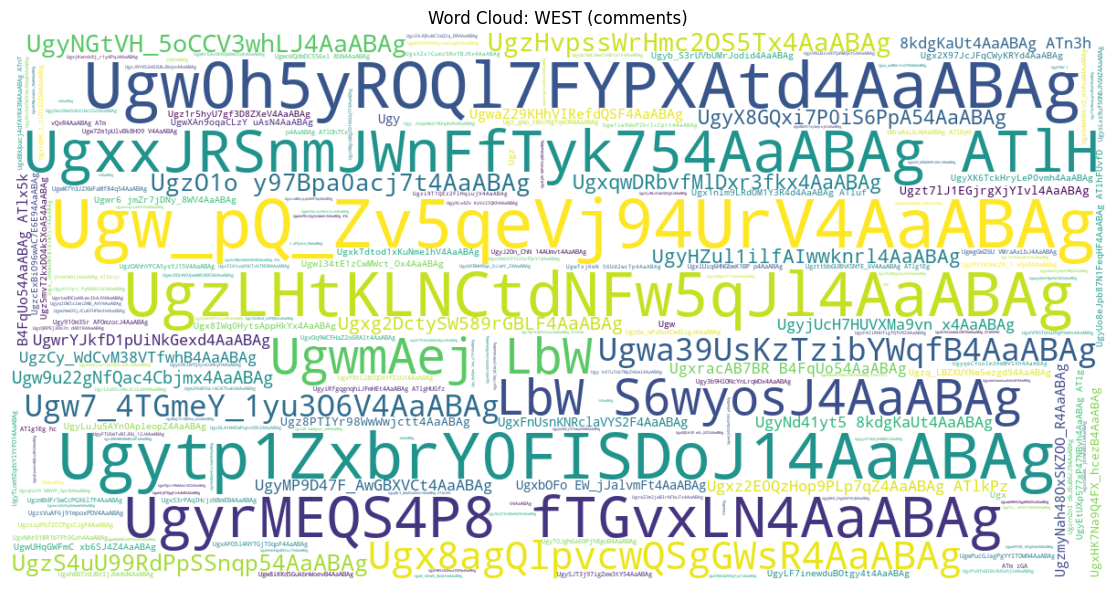


=== LDA Topics: WEST | transcripts ===
Topic 01: hit, east, middle, right, live, moment, action, uh, iranian, far, bahrain, tel
Topic 02: iran, regime, war, strike, strikes, leader, supreme, missile, missiles, tehran, year, change
Topic 03: region, going, white, house, israel, iranians, consequences, place, future, today, americans, israelis
Topic 04: israel, state, operation, minister, know, united, defense, preemptive, emergency, iran, dubai, launched
Topic 05: people, president, military, states, american, iranian, regime, region, bases, directly, united, troops
Topic 06: trump, donald, iran, president, country, just, government, regime, israel, media, iranian, ballistic


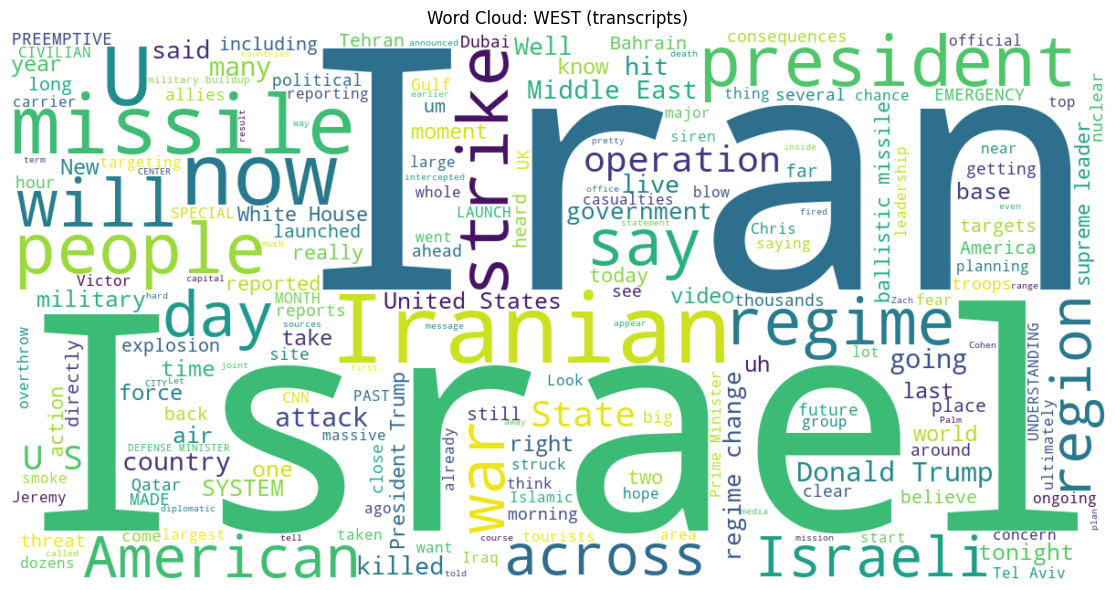


=== LDA Topics: MIDDLE_EAST | comments ===
Topic 01: aih6vrfn4aaabag, ugxgusaazj, ugwyxfqxfjvoahksuon4aaabag, ugwhs6tzcnwzdaofv_h4aaabag, ugwu9vsi8kw5bhwwl1r4aaabag, ugy, ugwqgqczt5art9lnbh94aaabag, ugyvvwunefqxhz3gdf54aaabag, ugyc8eajbnmkoetkxzf4aaabag, ugxocmcw8pxxti04mgt4aaabag, ugy48qn0gndt_nmx7ml4aaabag, ugy5v7pp
Topic 02: ugzsxckhvahzbnns4wl4aaabag, ugwnj2wsxyaeiv4hm214aaabag, ugyq1yehfnoohnh2nxp4aaabag, ugww6qwlvzo0, xdj5qt4aaabag, ugyhbqhtn0ic91vv5vb4aaabag, ugx3smazpxnw0ha5k4n4aaabag, ugx, ugzfraptqn63xt3wm_n4aaabag, atmo8d, ugxsmytmdi5uahdmqp94aaabag, f4aaabag
Topic 03: ugxmqicujk5bxnz, q3v4aaabag, ugxz3a0a8rmcnqsj8ip4aaabag, ugywlbrw86sgcmtdam54aaabag, ugxaddmxajfnk01vafh4aaabag, ugzwv17xkf7frl00vvb4aaabag, ugxhoa2zsbymncrczrz4aaabag, atlkwn, ugwxpwrnnef6y8hyqyt4aaabag, atlo0, ugw4u3weu8z8q4hwghl4aaabag, ugxo5sc8qvcz_ruv7bz4aaabag
Topic 04: ugx6gviels7mmrzy0ln4aaabag, ugxwmkxmep5n4u, 7_bv4aaabag, ugwjx1s5b, fkqx2ksqd4aaabag, ugzjp5aoscvptfb5gpb4aaabag, ugzbrdqchtcl1qbiqfl4a

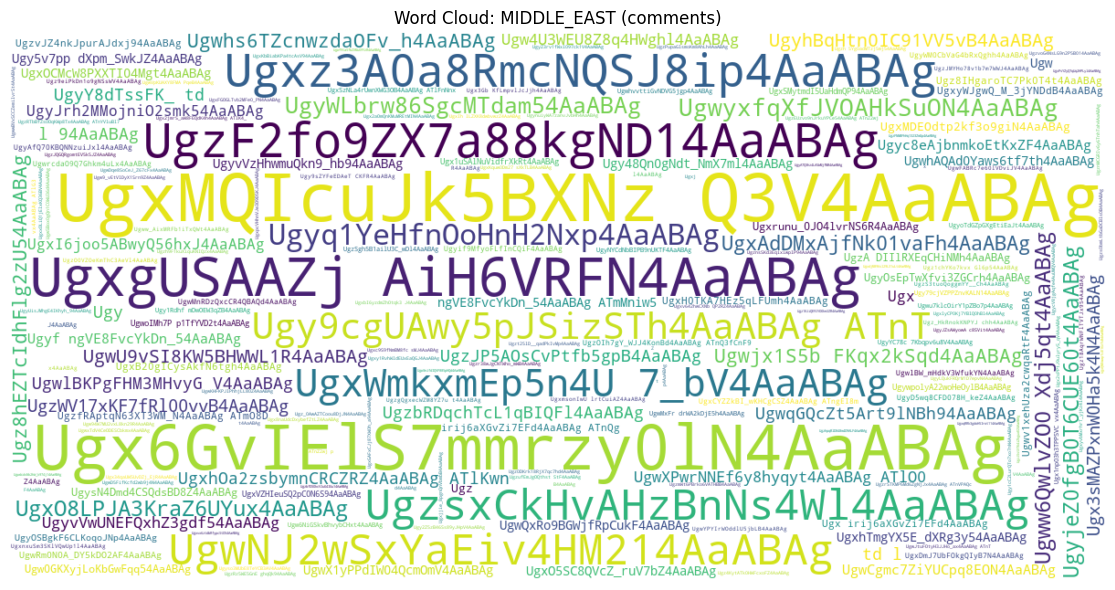


=== LDA Topics: MIDDLE_EAST | transcripts ===
Topic 01: think, iranian, going, trump, president, supreme, said, leader, look, say, days, national
Topic 02: uh, israeli, america, strike, israel, moment, james, going, regime, live, heard, um
Topic 03: uh, um, just, war, iran, nuclear, foreign, trump, president, states, daniel, talks
Topic 04: iran, region, strikes, israel, american, world, president, like, missiles, killed, country, long
Topic 05: uh, israel, um, iran, military, ve, israeli, know, region, public, buildup, alan
Topic 06: states, united, let, um, just, way, course, remember, bring, israel, political, islamic


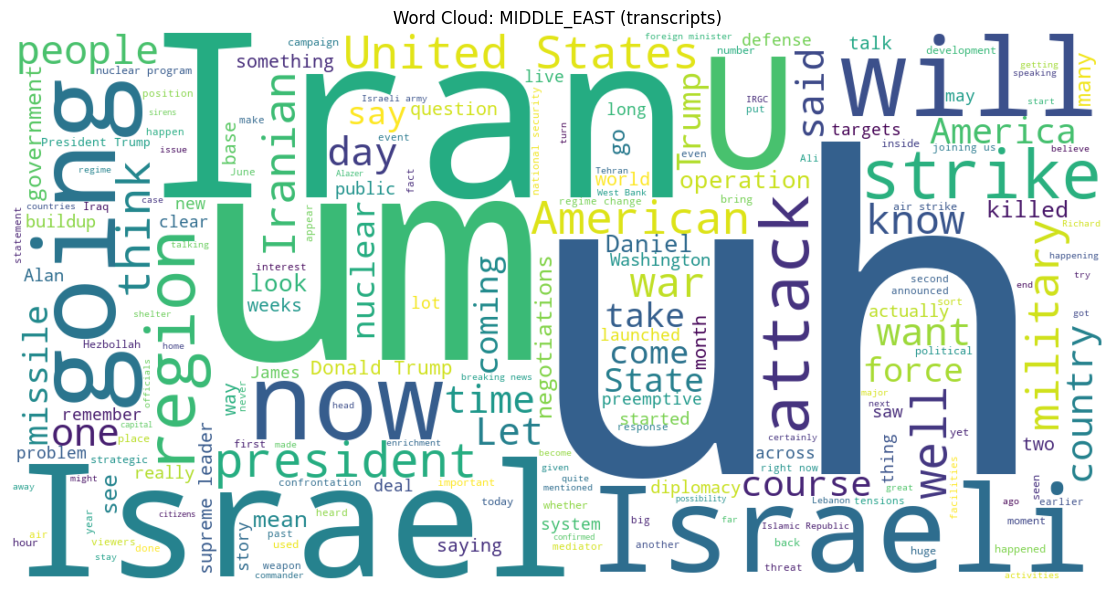


=== LDA Topics: INDIA | comments ===
Topic 01: ugz4, q29dwjsmjmrsb94aaabag, ugxyc8vcmnmbymnekzx4aaabag, atp6i7, ugzlkttcxj6x5g4xid94aaabag, ugzbvic52nze_cab2o14aaabag, ugwbg44opc0jc1t8wbh4aaabag, ugwxaefhsxctze_n5qd4aaabag, ugzx89n3salhy49ewgf4aaabag, ugzikna0anvbeutaxon4aaabag, ugxlamxu6xe1baiyhzt4aaabag, ugw
Topic 02: ugxlamxu6xe1baiyhzt4aaabag, ugzikna0anvbeutaxon4aaabag, ugzx89n3salhy49ewgf4aaabag, ugwxaefhsxctze_n5qd4aaabag, ugwbg44opc0jc1t8wbh4aaabag, ugzbvic52nze_cab2o14aaabag, ugzlkttcxj6x5g4xid94aaabag, ugw, ugznmecf9etmhwt0umf4aaabag, ugyelgt6udcylwkxe6p4aaabag, ugww4rfno2zr_ieowjh4aaabag, ugwp4hyouymoky_qnjd4aaabag
Topic 03: ugwkhnuz0ccgh1g9oqf4aaabag, ugzc2jbsepwksjjqd6j4aaabag, ugxs0lsd9r8tqu8ejfj4aaabag, ugy7zwybt3vs6yeawsd4aaabag, ugzkwwpkckya97zshs14aaabag, ugwaz_qf6xiju26gm814aaabag, ugzbvic52nze_cab2o14aaabag, ugzlkttcxj6x5g4xid94aaabag, ugwbg44opc0jc1t8wbh4aaabag, ugwxaefhsxctze_n5qd4aaabag, ugzx89n3salhy49ewgf4aaabag, ugzikna0anvbeutaxon4aaabag
Topic 04: ugx_jrcmsz

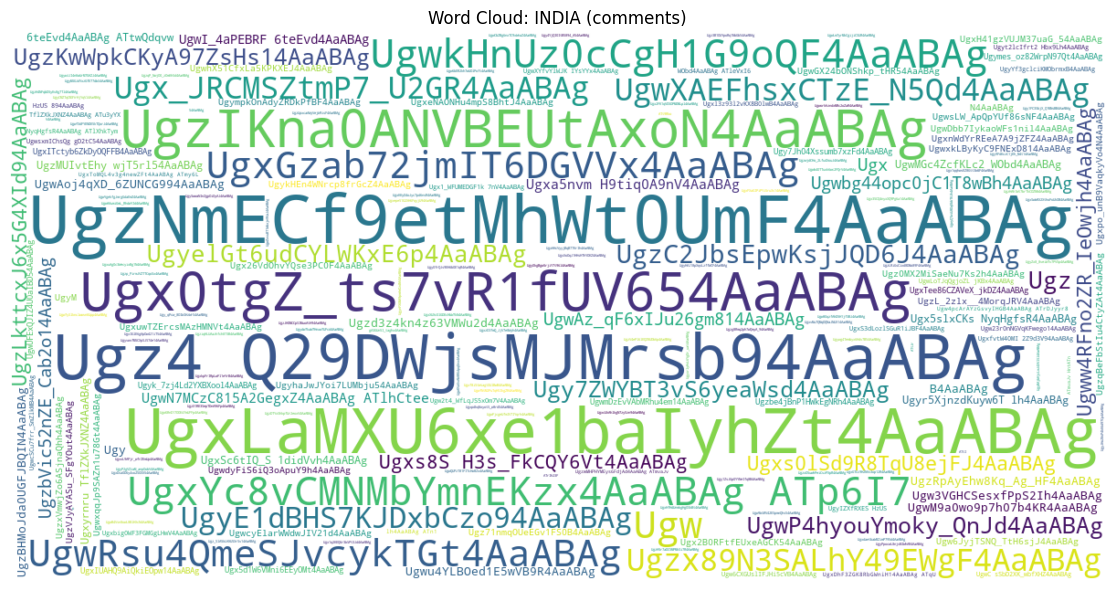


=== LDA Topics: INDIA | transcripts ===
Topic 01: think, time, india, attack, battle, iran, know, right, fact, going, air, aircraft
Topic 02: iran, war, don, chinese, iranian, trump, missile, regime, ll, president, want, donald
Topic 03: missiles, hit, american, know, iran, gulf, bases, got, iranian, days, just, stop
Topic 04: israel, america, know, iran, states, united, china, world, let, 000, mean, say
Topic 05: minister, prime, uh, fact, netanyahu, just, israel, countries, trump, pakistan, donald, modi
Topic 06: uh, iran, like, people, know, said, military, situation, saying, trump, strikes, killed


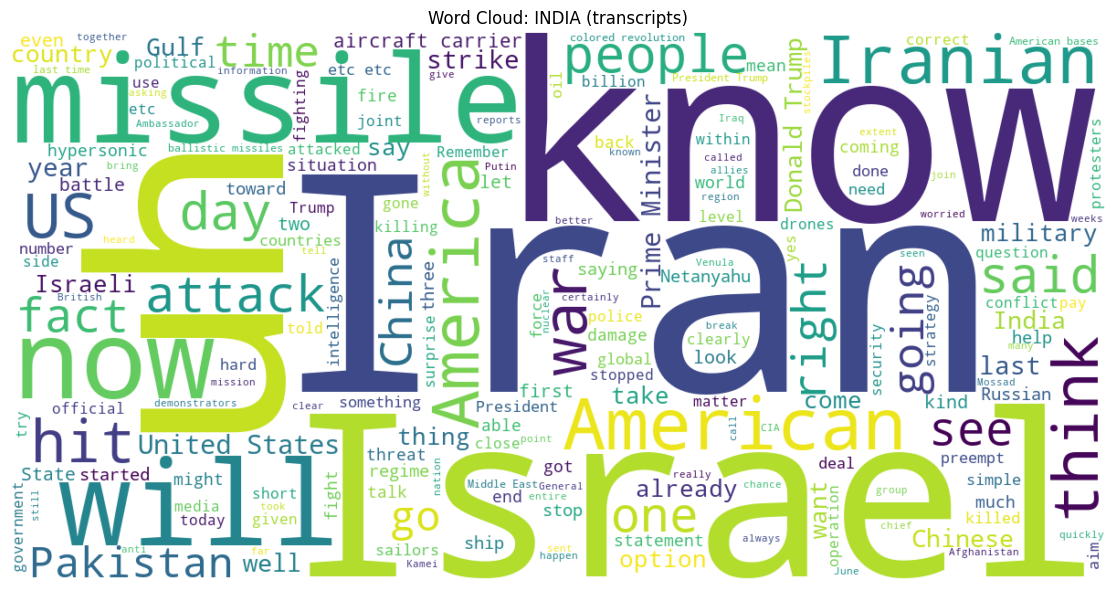

In [10]:

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def fit_lda(docs, n_topics=6, max_features=4000):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words="english",
        max_df=0.9,
        min_df=5,
        max_features=max_features
    )
    X = vectorizer.fit_transform(docs)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        learning_method="batch"
    )
    lda.fit(X)
    return lda, vectorizer, X

def top_words_per_topic(lda, feature_names, n_top_words=12):
    topics = []
    for topic_idx, topic in enumerate(lda.components_):
        top_idx = topic.argsort()[:-n_top_words-1:-1]
        words = [feature_names[i] for i in top_idx]
        topics.append((topic_idx, words))
    return topics

def make_wordcloud(text, title, outpath):
    wc = WordCloud(width=1200, height=600, background_color="white").generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()

def region_docs_comments(region):
    df = comments_df[comments_df["region"] == region].copy()
    return df["text_clean"].tolist()

def region_docs_transcripts(region):
    df = transcript_sents_df[transcript_sents_df["region"] == region].copy()
    return df["text_clean"].tolist()

def run_lda_for_region(region, docs, label):
    if len(docs) < 200:
        print(f"[WARN] Too few docs for {region}-{label}: {len(docs)}")
        return
    lda, vec, X = fit_lda(docs, n_topics=6, max_features=5000)
    feats = vec.get_feature_names_out()
    topics = top_words_per_topic(lda, feats, n_top_words=12)

    print(f"\n=== LDA Topics: {region} | {label} ===")
    for idx, words in topics:
        print(f"Topic {idx+1:02d}: " + ", ".join(words))

    # Wordcloud from ALL docs combined (good for region-wide themes)
    joined = " ".join(docs)
    outpath = OUTPUT_DIR / f"wordcloud_{region.lower()}_{label}.png"
    make_wordcloud(joined, f"Word Cloud: {region} ({label})", outpath)

for region in ["WEST","MIDDLE_EAST","INDIA"]:
    run_lda_for_region(region, region_docs_comments(region), "comments")
    run_lda_for_region(region, region_docs_transcripts(region), "transcripts")


## 10. Optional: word clouds per source outlet

If you want to show CNN vs BBC vs FOX separately (etc.), run this cell.


In [ ]:

def run_wordclouds_per_source(df, text_col, label):
    for (region, source), g in df.groupby(["region","source"]):
        joined = " ".join(g[text_col].tolist())
        if len(joined) < 2000:
            continue
        outpath = OUTPUT_DIR / f"wordcloud_{label}_{region.lower()}_{source.lower()}.png"
        make_wordcloud(joined, f"Word Cloud: {source} ({region}) [{label}]", outpath)

# Comments outlet-level clouds
run_wordclouds_per_source(comments_df, "text_clean", "comments")

# Transcript sentence outlet-level clouds
run_wordclouds_per_source(transcript_sents_df, "text_clean", "transcripts")


## 11. Export key tables (optional)

Saves:
- model CV results
- sentiment shares


In [ ]:

results_df.to_csv(OUTPUT_DIR / "cv_results_models.csv", index=False)

label_share(comments_df, "pred_label").to_csv(OUTPUT_DIR / "sentiment_share_comments_pred.csv", index=False)
label_share(transcript_sents_df, "pred_label").to_csv(OUTPUT_DIR / "sentiment_share_transcripts_pred.csv", index=False)

print("Saved to:", OUTPUT_DIR.resolve())
